### Individual Homework

#### Enter your name here: Elif Savar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Analysis of movies IMDB dataset**

We will look at a ***subset*** sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [2]:
movies = pd.read_csv('../Data/movies.csv')
movies

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0
...,...,...,...,...,...,...,...,...,...,...,...
2956,Locker 13,Thriller,Bruce Dellis,2014,95,2468,300000,2048,241,15,4.8
2957,The Ghastly Love of Johnny X,Comedy,Paul Bunnell,2012,106,2436,2000000,1611,344,113,5.7
2958,Detention of the Dead,Comedy,Alex Craig Mann,2012,87,1332,500000,2251,2038,49,4.6
2959,The Trials of Darryl Hunt,Crime,Ricki Stern,2006,106,1111,200000,2,771,21,7.7


Besides the obvious variables of `title`, `genre`, `director`, `year`, and `duration`, the rest of the variables are as follows:

-   `gross` : The gross earnings in the US box office, not adjusted for inflation
-   `budget`: The movie's budget
-   `cast_facebook_likes`: the number of facebook likes cast memebrs received
-   `votes`: the number of people who voted for (or rated) the movie in IMDB
-   `reviews`: the number of reviews for that movie
-   `rating`: IMDB average rating

**Produce a table with the count of movies by genre, ranked in descending order**


In [3]:
data = (movies.groupby('genre')
        .size()
        .reset_index(name='movie_count')
        .sort_values('movie_count', ascending=False)
        .reset_index(drop=True))
data

,genre,movie_count
0,Comedy,848
1,Action,738
2,Drama,498
3,Adventure,288
4,Crime,202
5,Biography,135
6,Horror,131
7,Animation,35
8,Fantasy,28
9,Documentary,25


**Produce a table with the average gross earning and budget (`gross` and `budget`) by genre. Calculate a variable `return_on_budget` which shows how many \$ did a movie make at the box office for each \$ of its budget. Ranked genres by this `return_on_budget` in descending order**

In [4]:
table = (movies
         .assign(genre=movies['genre'])
         .groupby('genre')
         .agg(
             gross=("gross","mean"),
             budget=("budget","mean")
         )
         .assign(
             return_on_budget=lambda x: x['gross'] / x['budget']
         )
         .sort_values("return_on_budget", ascending=False))
table

,gross,budget,return_on_budget
genre,,,
Musical,9.208400e+07,3.189500e+06,28.870983
Family,1.491605e+08,1.483333e+07,10.055763
Western,2.082188e+07,3.465000e+06,6.009202
Documentary,1.735397e+07,5.887852e+06,2.947420
Horror,3.771374e+07,1.350492e+07,2.792593
Fantasy,4.240884e+07,1.758214e+07,2.412040
Comedy,4.263055e+07,2.444632e+07,1.743843
Mystery,6.753302e+07,3.921875e+07,1.721958
Animation,9.843379e+07,6.170143e+07,1.595324


**Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director**

In [5]:
top_15_directors= (movies
                   .groupby("director")
                   .agg(
                       total_gross=("gross","sum"),
                       mean_gross=("gross","mean"),
                       median_gross=("gross","median"),
                       std_gross=("gross","std")
                   )
                   .sort_values("total_gross", ascending=False)
                   .head(15))
top_15_directors

,total_gross,mean_gross,median_gross,std_gross
director,,,,
Steven Spielberg,4014061704,1.745244e+08,164435221.0,1.014211e+08
Michael Bay,2231242537,1.716340e+08,138396624.0,1.271616e+08
Tim Burton,2071275480,1.294547e+08,76519172.0,1.087269e+08
Sam Raimi,2014600898,2.014601e+08,234903076.0,1.621266e+08
James Cameron,1909725910,3.182877e+08,175562880.5,3.091713e+08
Christopher Nolan,1813227576,2.266534e+08,196667606.5,1.872241e+08
George Lucas,1741418480,3.482837e+08,380262555.0,1.461939e+08
Robert Zemeckis,1619309108,1.245622e+08,100853835.0,9.130028e+07
Clint Eastwood,1378321100,7.254322e+07,46700000.0,7.548741e+07


**Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.**

/var/folders/6f/brg56v7543n6x3yk710q7lqc0000gn/T/ipykernel_21276/140614223.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  ax =sns.kdeplot(data=movies, x="rating", hue="genre", fill=True, alpha=.3, linewidth=0)


<function matplotlib.pyplot.show(close=None, block=None)>

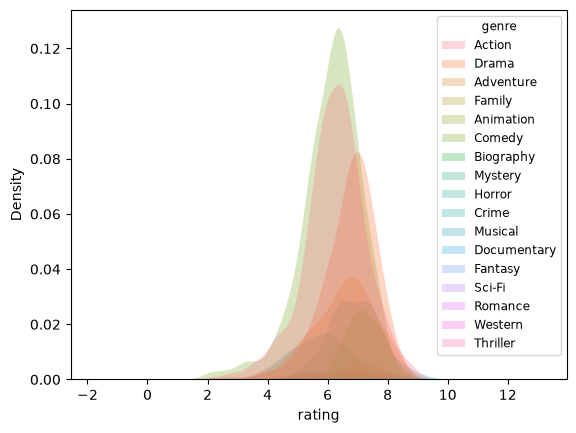

<Figure size 1600x800 with 0 Axes>

In [6]:
rating_distribution = (movies
                       .groupby("genre")
                       .agg(
                           mean_rating=("rating","mean"),
                           min_rating=("rating","min"),
                           max_rating=("rating","max"),
                           median_rating=("rating","median"),
                           std_rating=("rating","std")
                       ))
rating_distribution
ax =sns.kdeplot(data=movies, x="rating", hue="genre", fill=True, alpha=.3, linewidth=0)
plt.figure(figsize=(16, 8))
sns.move_legend(ax, "upper right", fontsize="small", title_fontsize="small", bbox_to_anchor=(1, 1))
plt.show

**Challenge - Produce a table of your own choosing, something you think is important/interesting to have data for, justify your result by writting a 2 sentence explanation/interpretation of the result.**

In [30]:
top_15_most_voted= (movies
                    .sort_values(by="votes", ascending=False)
                    .head(15))
top_15_most_voted[["title","votes","rating"]]
# I produced this table to identify the top 15 most popular movies based on their total vote counts.
#As popularity is a strong indicator of a movies cultural impact.
#The results show the classics like The shawsank redemption and The dark knight dominate the list, and notably
#Almost all off these highly voted movies also have exceptionally high IMDb rates. 

,title,votes,rating
1673,The Shawshank Redemption,1689764,9.3
4,The Dark Knight,1676169,9.0
56,Inception,1468200,8.8
1422,Fight Club,1347461,8.8
465,Pulp Fiction,1324680,8.9
41,Forrest Gump,1251222,8.8
210,The Matrix,1217752,8.7
23,The Lord of the Rings: The Return of the King,1215718,8.9
312,The Godfather,1155770,9.2
8,The Dark Knight Rises,1144337,8.5


#### Use visualisation to answer the following questions

**Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?**

<function matplotlib.pyplot.show(close=None, block=None)>

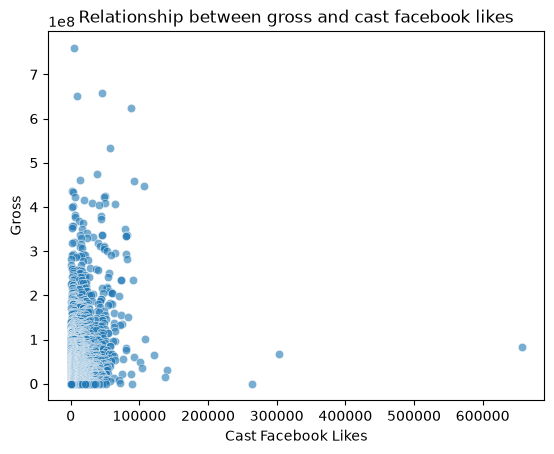

In [26]:
sns.scatterplot(data=movies, x="cast_facebook_likes",y="gross",alpha=0.6)
plt.title("Relationship between gross and cast facebook likes")
plt.xlabel("Cast Facebook Likes")
plt.ylabel("Gross")
plt.show
#Relationship between the gross and cast_facebook likes are slighty positive but weak. 
#So Cast Facebook likes are not a strong predictor of box offices. 

**Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.**

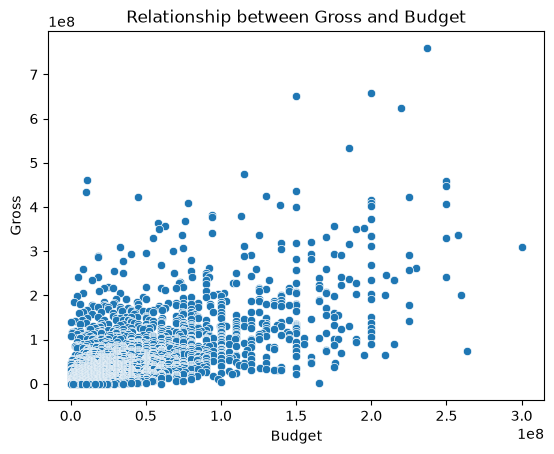

In [24]:
sns.scatterplot(data=movies, x="budget",y="gross")
plt.title("Relationship between Gross and Budget")
plt.xlabel("Budget")
plt.ylabel("Gross")
plt.show()
#More budget tend to bring a high gross, so the relationship between these two are really strong.

**Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?**

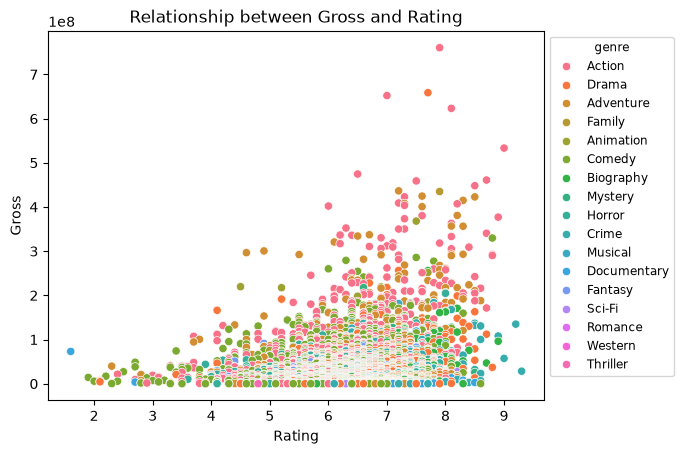

In [ ]:
ay=sns.scatterplot(data=movies, x="rating",y="gross", hue="genre")
sns.move_legend(ay, "upper left", fontsize="small", title_fontsize="small", bbox_to_anchor=(1, 1))
plt.title("Relationship between Gross and Rating")
plt.xlabel("Rating")
plt.ylabel("Gross")
plt.show()
#IMDb ratings are not a good predictor of box office gross. The scatterplot shows shows a very weak relationship.
#Something strange in this dataset is some of the very low rating movies have an exceptionally high gross, which is unusual.
#Additionally there is some some gap in ratings between 4 and 6.

**Challenge - Produce a visualisation of your choosing, something you think is important to explore/investigate visually. Do make it a comprehensive graph and not a single histogram or density plot. Make it publication ready, label your axes, give it a title, choose colouring options, appropirately formatted text etc.**

/var/folders/6f/brg56v7543n6x3yk710q7lqc0000gn/T/ipykernel_21276/3852268610.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_votes,x="votes",y="genre",palette="magma")


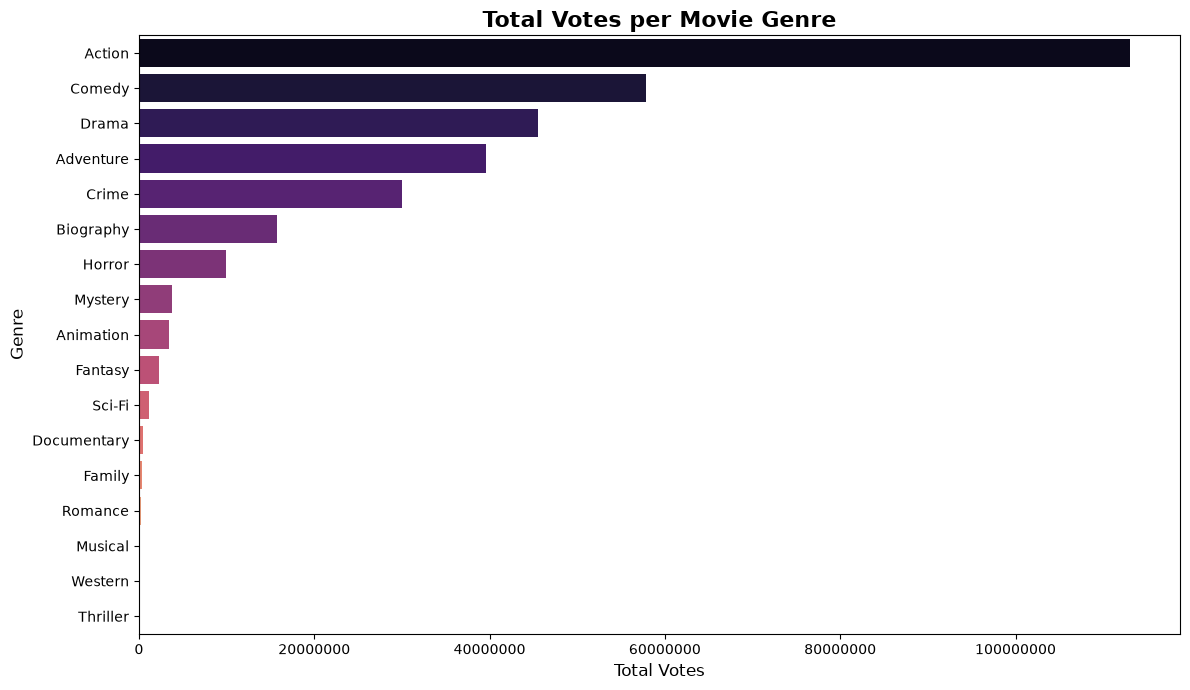

In [29]:
genre_votes= movies.groupby("genre")["votes"].sum().reset_index()
genre_votes=genre_votes.sort_values(by="votes",ascending=False)
plt.figure(figsize=(12,7))
sns.barplot(data=genre_votes,x="votes",y="genre",palette="magma")
plt.title("Total Votes per Movie Genre",fontsize=16, fontweight="bold")
plt.xlabel("Total Votes",fontsize=12)
plt.ylabel("Genre",fontsize=12)
plt.ticklabel_format(style="plain",axis="x")

plt.tight_layout()
plt.show()
#This bar chart shows the total number of votes aggregated by genre. Action and drama are by far the most voted genres.
#That shows they have the largest audience engagement, whereas Westerns and Musicals receive the least amount of votes.

### Deliverables

Poduce a clean, stand-alone notebook (or HTML export) with:

All tables/plots properly labeled

Brief interpretations where requested

Upload final HTML/Notebook.